In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.nddata import extract_array
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from reproject import reproject_interp
from astropy.visualization import make_lupton_rgb
from astropy.wcs import utils
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle
from matplotlib.patches import ConnectionPatch

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from astropy.visualization.wcsaxes import WCSAxes
import astropy.units as u

In [2]:
npath = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/'
miri_north_files = [npath+'North_f770w.fits',npath+'North_f1000w.fits',npath+'North_f1130w.fits',npath+"North_f2100w.fits"]

# Open all fits images
miri770_hdu  = fits.open(miri_north_files[0])
miri1000_hdu = fits.open(miri_north_files[1])
miri1130_hdu = fits.open(miri_north_files[2])
miri2100_hdu = fits.open(miri_north_files[3])

miri_770_data_r    = miri770_hdu[0].data
miri_1000_data_r   = miri1000_hdu[0].data
miri_1130_data_r   = miri1130_hdu[0].data
miri_2100_data_r   = miri2100_hdu[0].data

miri_770_header = miri770_hdu[0].header

wcs_770  = WCS(miri770_hdu[0].header)
wcs_1000 = WCS(miri1000_hdu[0].header)
wcs_1130 = WCS(miri1130_hdu[0].header)
wcs_2100 = WCS(miri2100_hdu[0].header)

# Handle Nans; set Nans to 0
miri_770_data_r[np.isnan(miri_770_data_r)] = 0
miri_1000_data_r[np.isnan(miri_1000_data_r)] = 0
miri_1130_data_r[np.isnan(miri_1130_data_r)] = 0
miri_2100_data_r[np.isnan(miri_2100_data_r)] = 0

# How to handle negative values? Not sure. Going to set to 0
miri_770_data_r[miri_770_data_r<0] = 0.01
miri_1000_data_r[miri_1000_data_r<0] = 0.01
miri_1130_data_r[miri_1130_data_r<0] = 0.01
miri_2100_data_r[miri_2100_data_r<0] = 0.01


Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [3]:
# Convert FK4 to FK5
wcs_fk5 = wcs_770.deepcopy()
wcs_fk5.wcs.equinox = 2000.0
wcs_fk5.wcs.ctype = ['RA---TAN', 'DEC--TAN']
wcs_fk5.wcs.radesys = 'ICRS'

print(wcs_fk5.wcs.radesys)  # Should output 'ICRS' or 'FK5'
print(wcs_fk5.wcs.equinox)  # Should be 2000.0

ICRS
2000.0


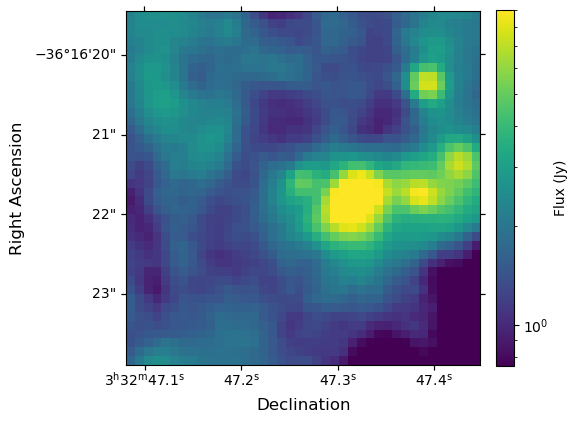

In [4]:
# Image pixel location of SN 83V taken from DS9
x = 4856
y = 4049

# x = round(1139)
# y = round(1244)
# Crop image with indexing to focus on SN -- for cropping, [y,x]
window = 20
y0 = y-window
y1 = y+window
x0 = x-window
x1 = x+window

# Crop region (same as before)
crop_small = (slice(y0, y1), slice(x0, x1))

# Set figure space
fig = plt.figure(figsize=(5,5))
ax = plt.subplot(projection = wcs_fk5)

# plot image in log space
miri770 = ax.imshow(miri_770_data_r[crop_small], norm='log', vmax=9, vmin=0.75)

# axis labels and params
ax.set_ylabel('Right Ascension', fontsize = 12)
ax.set_xlabel('Declination', fontsize =12)

# colorbar
plt.colorbar(miri770, label='Flux (Jy)', fraction=0.046, pad=0.04)

plt.show()




In [5]:
# Reproject other images onto the reference WCS
miri_1000_reproj, _ = reproject_interp((miri_1000_data_r, miri1000_hdu[0].header), wcs_fk5)
miri_1130_reproj, _ = reproject_interp((miri_1130_data_r, miri1130_hdu[0].header), wcs_fk5)
miri_2100_reproj, _ = reproject_interp((miri_2100_data_r, miri2100_hdu[0].header), wcs_fk5)


Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


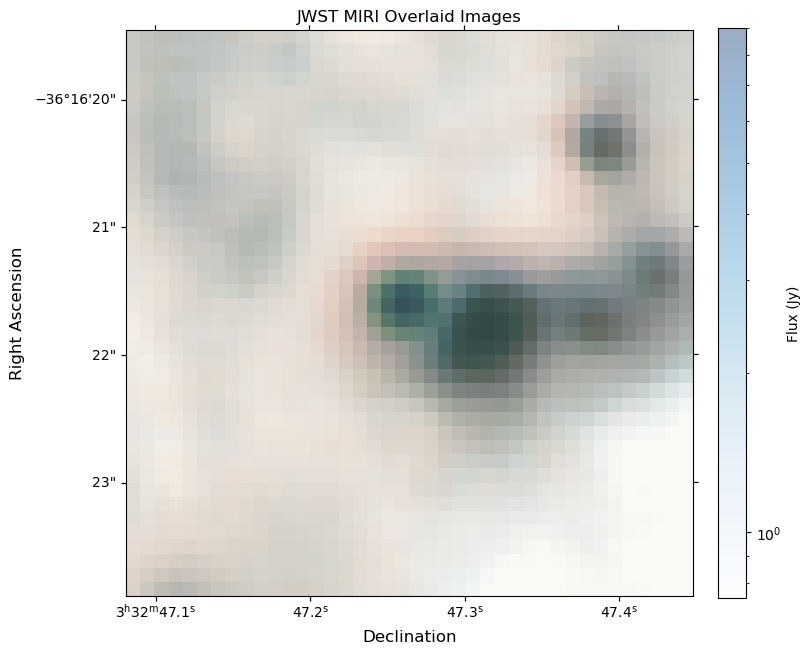

In [6]:
# plot MIRI image overlay in all filters
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs_770)

inorm0 = 'log'
ivmin0 = 0.75
ivmax0 = 9
# 'log', vmax=9, vmin=0.75
# 'linear',vmax=6, vmin=0


# Overlay images with transparency and different colormaps
ax.imshow(miri_2100_reproj[crop_small], norm=inorm0, cmap='Reds', alpha=0.7, vmin=ivmin0, vmax=ivmax0)
ax.imshow(miri_1130_reproj[crop_small], norm=inorm0, cmap='Oranges', alpha=0.6, vmin=ivmin0, vmax=ivmax0)
ax.imshow(miri_1000_reproj[crop_small], norm=inorm0, cmap='Greens', alpha=0.5, vmin=ivmin0, vmax=ivmax0)
base = ax.imshow(miri_770_data_r[crop_small], norm=inorm0, cmap='Blues', alpha=0.4, vmin=ivmin0, vmax=ivmax0)

ax.set_ylabel('Right Ascension', fontsize=12)
ax.set_xlabel('Declination', fontsize=12)
plt.colorbar(base, label='Flux (Jy)', fraction=0.046, pad=0.04)
plt.title('JWST MIRI Overlaid Images')
plt.show()

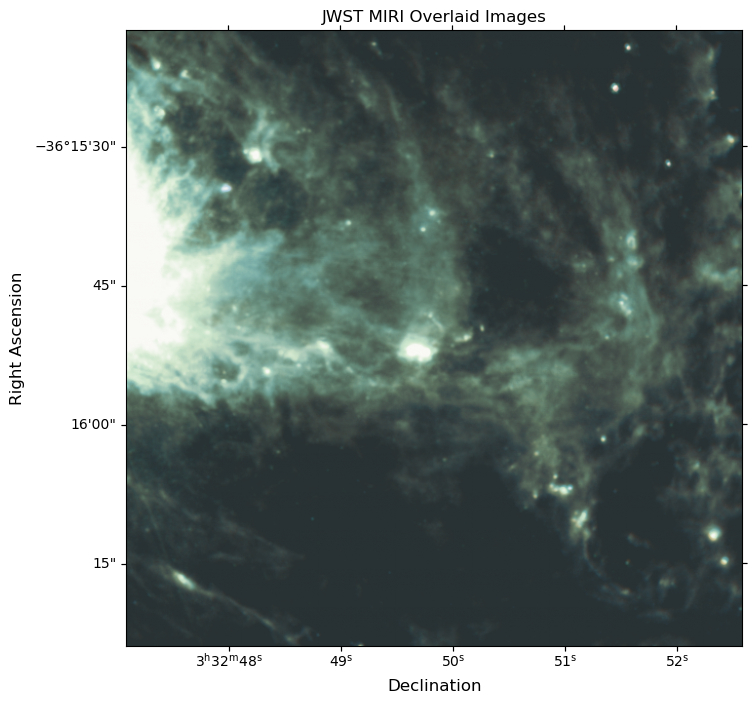

In [35]:
# plot MIRI image overlay in all filters
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs_770)

centerx = 4988
centery = 4196

xsize = 600
ysize = 600

x0 = centerx - xsize//2
x1 = centerx + xsize//2
y0 = centery - ysize//2
y1 = centery + ysize//2

crop_big = (slice(y0, y1), slice(x0, x1))
inorm1 = 'linear'
ivmin1 = 0.1
ivmax1 = 8

# Overlay images with transparency and different colormaps
ax.imshow(np.fliplr(miri_2100_reproj[crop_big]), norm=inorm1, cmap='Reds_r', alpha=1, vmin=ivmin1, vmax=ivmax1)
ax.imshow(np.fliplr(miri_1130_reproj[crop_big]), norm=inorm1, cmap='Oranges_r', alpha=0.9, vmin=ivmin1, vmax=ivmax1)
ax.imshow(np.fliplr(miri_1000_reproj[crop_big]), norm=inorm1, cmap='Greens_r', alpha=0.5, vmin=ivmin1, vmax=ivmax1)
base = ax.imshow(np.fliplr(miri_770_data_r[crop_big]), norm=inorm1, cmap='Blues_r', alpha=0.4, vmin=ivmin1, vmax=ivmax1)

ax.set_ylabel('Right Ascension', fontsize=12)
ax.set_xlabel('Declination', fontsize=12)
# plt.colorbar(base, label='Flux (Jy)', fraction=0.046, pad=0.04)
plt.title('JWST MIRI Overlaid Images')
plt.show()

In [36]:
# Convert FK4 to FK5
wcs_fk5 = wcs_770.deepcopy()
wcs_fk5.wcs.equinox = 2000.0
wcs_fk5.wcs.ctype = ['RA---TAN', 'DEC--TAN']
wcs_fk5.wcs.radesys = 'ICRS'

print(wcs_fk5.wcs.radesys)  # Should output 'ICRS' or 'FK5'
print(wcs_fk5.wcs.equinox)  # Should be 2000.0

ICRS
2000.0


/var/folders/q3/hykz569d1r1c51lc9dq_8cb00000gn/T/ipykernel_6602/2693107006.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


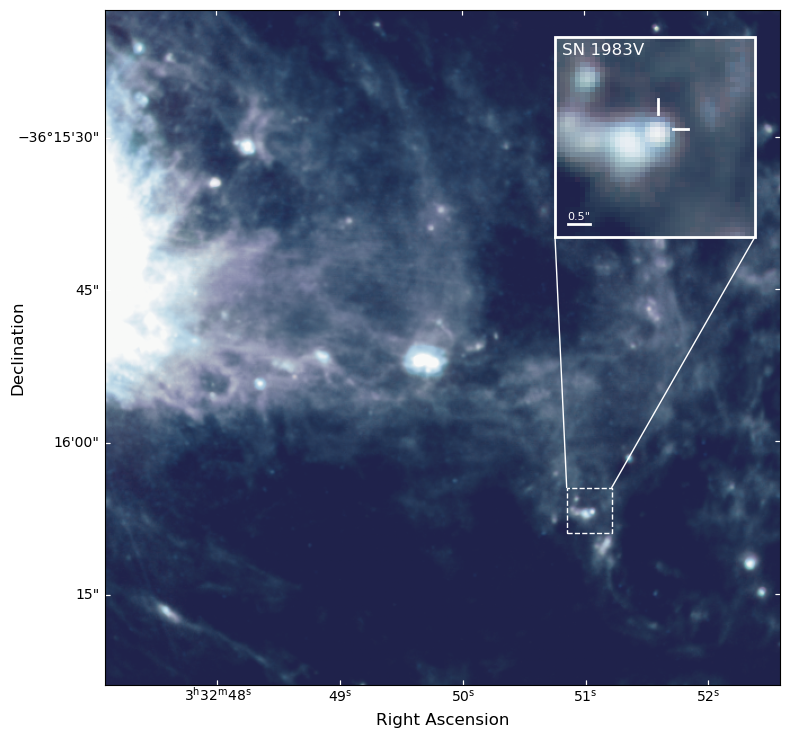

In [65]:
# Create the main figure
fig = plt.figure(figsize=(8, 8))

##################################
# BIG IMAGE (Main panel)
main_ax = fig.add_subplot(1, 1, 1, projection=wcs_fk5)

# Overlay main image
main_ax.imshow(np.fliplr(miri_2100_reproj[crop_big]), norm=inorm1, cmap='Reds_r', alpha=1, vmin=ivmin1, vmax=ivmax1)
main_ax.imshow(np.fliplr(miri_1130_reproj[crop_big]), norm=inorm1, cmap='Greens_r', alpha=0.6, vmin=ivmin1, vmax=ivmax1)
main_ax.imshow(np.fliplr(miri_1000_reproj[crop_big]), norm=inorm1, cmap='Blues_r', alpha=0.5, vmin=ivmin1, vmax=ivmax1)
main_ax.imshow(np.fliplr(miri_770_data_r[crop_big]), norm=inorm1, cmap='Purples_r', alpha=0.2, vmin=ivmin1, vmax=ivmax1)

main_ax.set_xlabel('Right Ascension', fontsize=12)
main_ax.set_ylabel('Declination', fontsize=12, labelpad=0.00001)
main_ax.tick_params(axis='both', direction='in', color='white')

# main_ax.text(440, 940, 'A', fontsize=40, color='black')


##################################
# ZOOM IN

# Define inset position in figure fraction coordinates
inset_bounds = [0.7, 0.49, 0.25, 0.6]  # [left, bottom, width, height] in fig coordinates
inset_ax = WCSAxes(fig, inset_bounds, wcs=wcs_fk5)
fig.add_axes(inset_ax)

rect = plt.Rectangle(
    (0.7, 0.665),   # lower left in figure coords
    0.25, 0.25,     # width, height
    transform=fig.transFigure,            # use figure coords
    edgecolor="white",                   # border color
    facecolor="none",
    linewidth=2,
    zorder=10
)

fig.patches.append(rect)
# Remove coordinate ticks and labels from inset axes
inset_ax.coords[0].set_ticks_visible(False)
inset_ax.coords[1].set_ticks_visible(False)
inset_ax.coords[0].set_ticklabel_visible(False)
inset_ax.coords[1].set_ticklabel_visible(False)

# Optional: turn off grid if it's on
inset_ax.grid(False)

# Overlay zoomed image
inset_ax.imshow(np.fliplr(miri_2100_reproj[crop_small]), norm=inorm0, cmap='Reds_r', alpha=1, vmin=ivmin0, vmax=ivmax0)
inset_ax.imshow(np.fliplr(miri_1130_reproj[crop_small]), norm=inorm0, cmap='Greens_r', alpha=0.6, vmin=ivmin0, vmax=ivmax0)
inset_ax.imshow(np.fliplr(miri_1000_reproj[crop_small]), norm=inorm0, cmap='Blues_r', alpha=0.5, vmin=ivmin0, vmax=ivmax0)
inset_ax.imshow(np.fliplr(miri_770_data_r[crop_small]), norm=inorm0, cmap='Purples_r', alpha=0.2, vmin=ivmin0, vmax=ivmax0)

# Cleanup
inset_ax.set_xlabel('')
inset_ax.set_ylabel('')
# inset_ax.tick_params(axis='both', which='both', direction='in', labelsize=8, color='white')


##################################
inset_ax.text(1, 36, 'SN 1983V', fontsize=12, color='white')
# inset_ax.text(1, 1, 'B', fontsize=24, color='black')

##################################
# zoom in box
# Define zoom box coordinates
x1, y1 = 410, 135
zoom_width = 40
zoom_height = 40

main_ax.add_patch(Rectangle((x1, y1), width=zoom_width, height=zoom_height,
                            edgecolor='white', facecolor='none',linestyle='--'))

##################################
# Crosshairs in zoom inset
window = 19  # adjust if needed
hx_line = [(window)+4, (window)+7]
hy_line = [(window+2), (window+2)]
vx_line = [(window+1), (window+1)]
vy_line = [(window)+5, (window)+8]

inset_ax.plot(hx_line, hy_line, color='white', linewidth=2)
inset_ax.plot(vx_line, vy_line, color='white', linewidth=2)
##################################
# Scale bar
x0, y0 = 2, 2
sc_x = [x0, x0+4.5]
sc_y = [y0, y0]

inset_ax.plot(sc_x, sc_y, color='white', linewidth=2)
inset_ax.text(x0, y0 + 1, '0.5"', fontsize=8, color='white')

##################################
# Connection lines
zoom_x, zoom_y = x1, y1 + zoom_height

# Match to corners of inset (bottom left and top left)
con1 = ConnectionPatch(xyA=(0, 0), coordsA=inset_ax.transAxes,
                       xyB=(zoom_x, zoom_y), coordsB=main_ax.transData,
                       color='white')
con2 = ConnectionPatch(xyA=(1, 0.0), coordsA=inset_ax.transAxes,
                       xyB=(zoom_x+zoom_width, y1+zoom_width), coordsB=main_ax.transData,
                       color='white')
fig.add_artist(con1)
fig.add_artist(con2)

##################################

# Done
plt.tight_layout()
plt.savefig("/Users/sophiakressy/Desktop/MIRI_SN1983V_zoom.pdf", dpi=300)
plt.show()

# Plot MIRI Images Overlaid

In [2]:
# Load the FITS files
path = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/lvl_3/'
miri1 = 'jw02107-c1003_t003_miri_f770w_jhat_i2d.fits'
miri2 = 'jw02107-c1003_t003_miri_f1000w_jhat_i2d.fits'
miri3 = 'jw02107-c1003_t003_miri_f1130w_jhat_i2d.fits'
miri4 = 'jw02107-c1003_t003_miri_f2100w_jhat_i2d.fits'
miri_files = [path+miri1, path+miri2,path+miri3, path+miri4]



In [3]:
# (This can all be streamlined later)

# Open all fits images
miri770_hdu = fits.open(miri_files[0])
miri1000_hdu = fits.open(miri_files[1])
miri1130_hdu = fits.open(miri_files[2])
miri2100_hdu = fits.open(miri_files[3])

# reference image for other images to reproject on
# recommend that this ref image is the highest resolution of the group.
miri_770_data   = miri770_hdu[1].data
miri_770_header = miri770_hdu[1].header
wcs = WCS(miri770_hdu[1].header)
print(wcs)

# grab rest of data
miri_1000_data   = miri1000_hdu[1].data
miri_1130_data   = miri1130_hdu[1].data
miri_2100_data   = miri2100_hdu[1].data


# miri_hdu.info()
# plt.imshow(miri_770_data)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 53.379789290286 -36.187893752187 
CRPIX : 2406.0752860072 1386.2103971277 
PC1_1 PC1_2  : 0.071660147640828 -0.99770962587912 
PC2_1 PC2_2  : -0.99736365210609 -0.07236736271246 
CDELT : 3.0811802513623e-05 3.0811802513623e-05 
NAXIS : 4805  2777


Set DATE-AVG to '2022-08-13T15:46:20.295' from MJD-AVG.
Set DATE-END to '2022-08-13T18:20:48.239' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [4]:
# Handle Nans; set Nans to 0
miri_770_data[np.isnan(miri_770_data)] = 0
miri_1000_data[np.isnan(miri_1000_data)] = 0
miri_1130_data[np.isnan(miri_1130_data)] = 0
miri_2100_data[np.isnan(miri_2100_data)] = 0

# How to handle negative values? Not sure. Going to set to 0
miri_770_data[miri_770_data<0] = 0.01
miri_1000_data[miri_1000_data<0] = 0.01
miri_1130_data[miri_1130_data<0] = 0.01
miri_2100_data[miri_2100_data<0] = 0.01

## Sanity Check

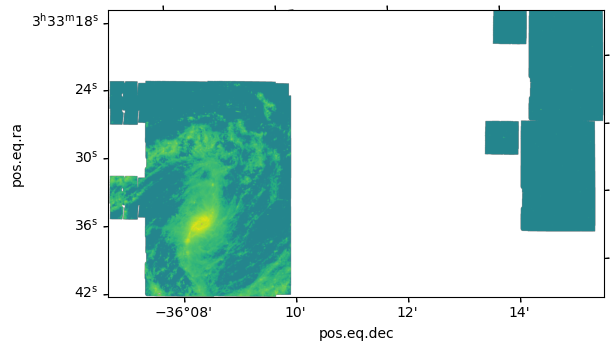

In [5]:
# plot 770 as an example, make sure something appears!
# miri_770_flipped = np.flip(miri_770_data, axis=0)
fig = plt.figure()
ax = plt.subplot( projection = wcs)
ax.imshow(miri_770_data,norm='log')

## Establish Zoomed-in region coords; 770 as ref pic; Sanity check

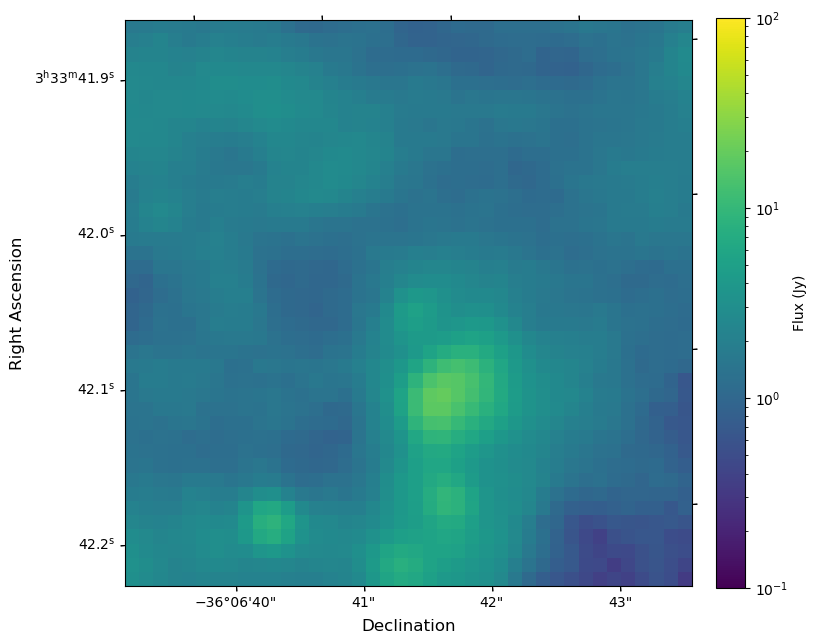

In [27]:
# Image pixel location of SN 83V taken from DS9
x = round(1139)
y = round(1244)
# Crop image with indexing to focus on SN -- for cropping, [y,x]
window = 20
y0 = y-window
y1 = y+window
x0 = x-window
x1 = x+window

# Crop region (same as before)
crop_small = (slice(y0, y1), slice(x0, x1))

# Set figure space
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(projection = wcs)

# plot image in log space
miri770 = ax.imshow(miri_770_data[crop_small], norm='log', vmax=100, vmin=0.1)

# axis labels and params
ax.set_ylabel('Right Ascension', fontsize = 12)
ax.set_xlabel('Declination', fontsize =12)

# colorbar
plt.colorbar(miri770, label='Flux (Jy)', fraction=0.046, pad=0.04)

plt.show()

# Extra plotting tricks if need later
# ax.tick_params(axis='x', labelsize=12, direction="in", color = 'white', width = 1, length = 7)
# ax.tick_params(axis='y', labelsize=12, direction="in", color = 'white', width = 1, length = 7)





## Reproject other filters onto 770

In [7]:
# Reproject other images onto the reference WCS
miri_1000_reproj, _ = reproject_interp((miri_1000_data, miri1000_hdu[1].header), miri_770_header)
miri_1130_reproj, _ = reproject_interp((miri_1130_data, miri1130_hdu[1].header), miri_770_header)
miri_2100_reproj, _ = reproject_interp((miri_2100_data, miri2100_hdu[1].header), miri_770_header)


Set DATE-AVG to '2022-08-13T15:46:20.295' from MJD-AVG.
Set DATE-END to '2022-08-13T18:20:48.239' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


## Plot zoomed-in region in Linear

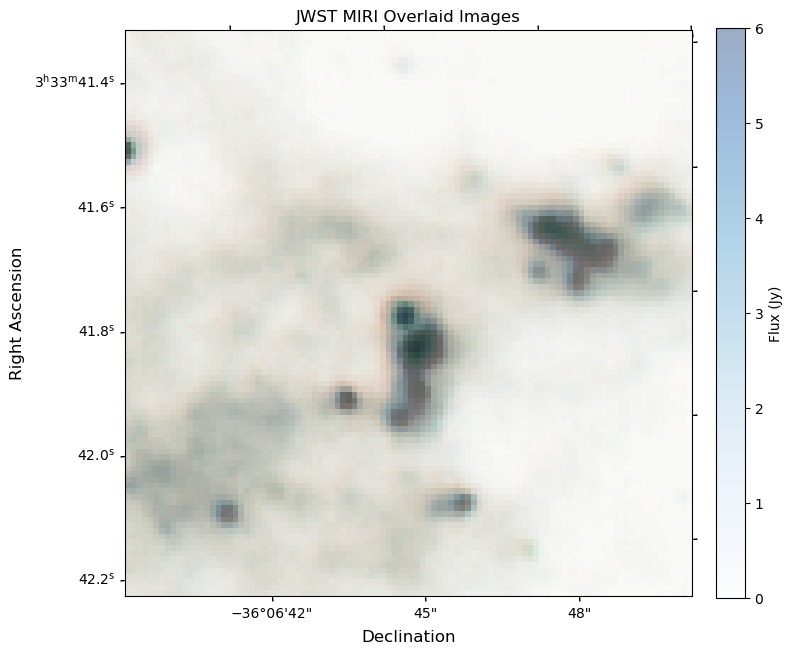

In [8]:
# plot MIRI image overlay in all filters
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

inorm0 = 'linear'
ivmin0 = 0
ivmax0 = 6


# Overlay images with transparency and different colormaps
ax.imshow(miri_2100_reproj[crop_small], norm=inorm0, cmap='Reds', alpha=0.7, vmin=ivmin0, vmax=ivmax0)
ax.imshow(miri_1130_reproj[crop_small], norm=inorm0, cmap='Oranges', alpha=0.6, vmin=ivmin0, vmax=ivmax0)
ax.imshow(miri_1000_reproj[crop_small], norm=inorm0, cmap='Greens', alpha=0.5, vmin=ivmin0, vmax=ivmax0)
base = ax.imshow(miri_770_data[crop_small], norm=inorm0, cmap='Blues', alpha=0.4, vmin=ivmin0, vmax=ivmax0)

ax.set_ylabel('Right Ascension', fontsize=12)
ax.set_xlabel('Declination', fontsize=12)
plt.colorbar(base, label='Flux (Jy)', fraction=0.046, pad=0.04)
plt.title('JWST MIRI Overlaid Images')
plt.show()

## Linear Zoom-out of Galaxy

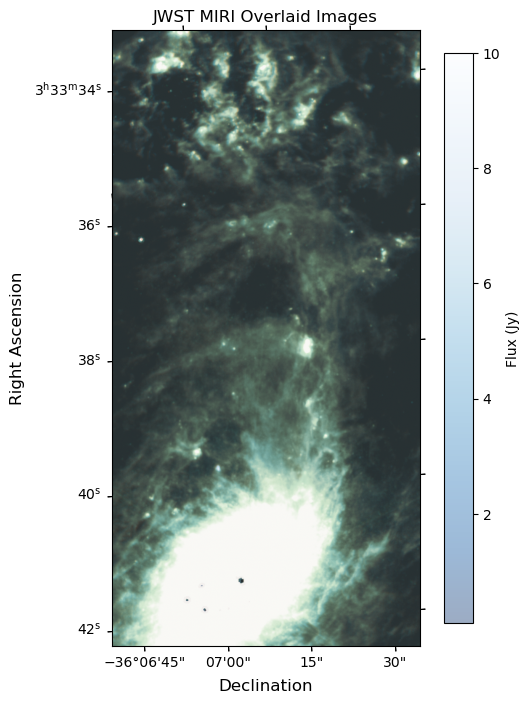

In [13]:
# plot MIRI image overlay in all filters
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

crop_big = (slice(600, 1600), slice(700, 1200))
inorm1 = 'linear'
ivmin1 = .1
ivmax1 = 10

# Overlay images with transparency and different colormaps
ax.imshow(miri_2100_reproj[crop_big], norm=inorm1, cmap='Reds_r', alpha=1, vmin=ivmin1, vmax=ivmax1)
ax.imshow(miri_1130_reproj[crop_big], norm=inorm1, cmap='Oranges_r', alpha=0.9, vmin=ivmin1, vmax=ivmax1)
ax.imshow(miri_1000_reproj[crop_big], norm=inorm1, cmap='Greens_r', alpha=0.5, vmin=ivmin1, vmax=ivmax1)
base = ax.imshow(miri_770_data[crop_big], norm=inorm1, cmap='Blues_r', alpha=0.4, vmin=ivmin1, vmax=ivmax1)

ax.set_ylabel('Right Ascension', fontsize=12)
ax.set_xlabel('Declination', fontsize=12)
plt.colorbar(base, label='Flux (Jy)', fraction=0.046, pad=0.04)
plt.title('JWST MIRI Overlaid Images')
plt.show()

/Users/sophiakressy/miniconda3/lib/python3.12/site-packages/astropy/visualization/lupton_rgb.py:645: RuntimeWarning: invalid value encountered in divide
  fInorm = np.where(Int <= 0, 0, np.true_divide(fI, Int))


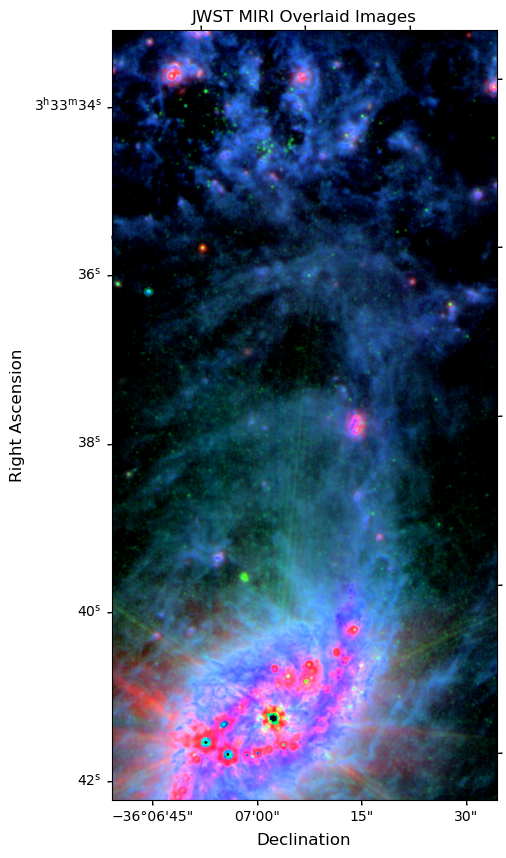

In [14]:
# image = make_lupton_rgb(miri_2100_reproj[crop], miri_1000_reproj[crop], miri_770_data[crop], stretch=4, Q=6)
r = miri_2100_reproj[600:1600,700:1200]
g = miri_1000_reproj[600:1600,700:1200]
b = miri_770_data[600:1600,700:1200]
image = make_lupton_rgb(r, g*3, b*2, stretch=8, Q=5)

fig = plt.figure(figsize=(16,10))#figsize=(8,8)
ax = plt.subplot(projection = wcs)
ax.set_ylabel('Right Ascension', fontsize=12)
ax.set_xlabel('Declination', fontsize=12)
plt.title('JWST MIRI Overlaid Images')
ax.imshow(image)



# Zoomed-in MIRI

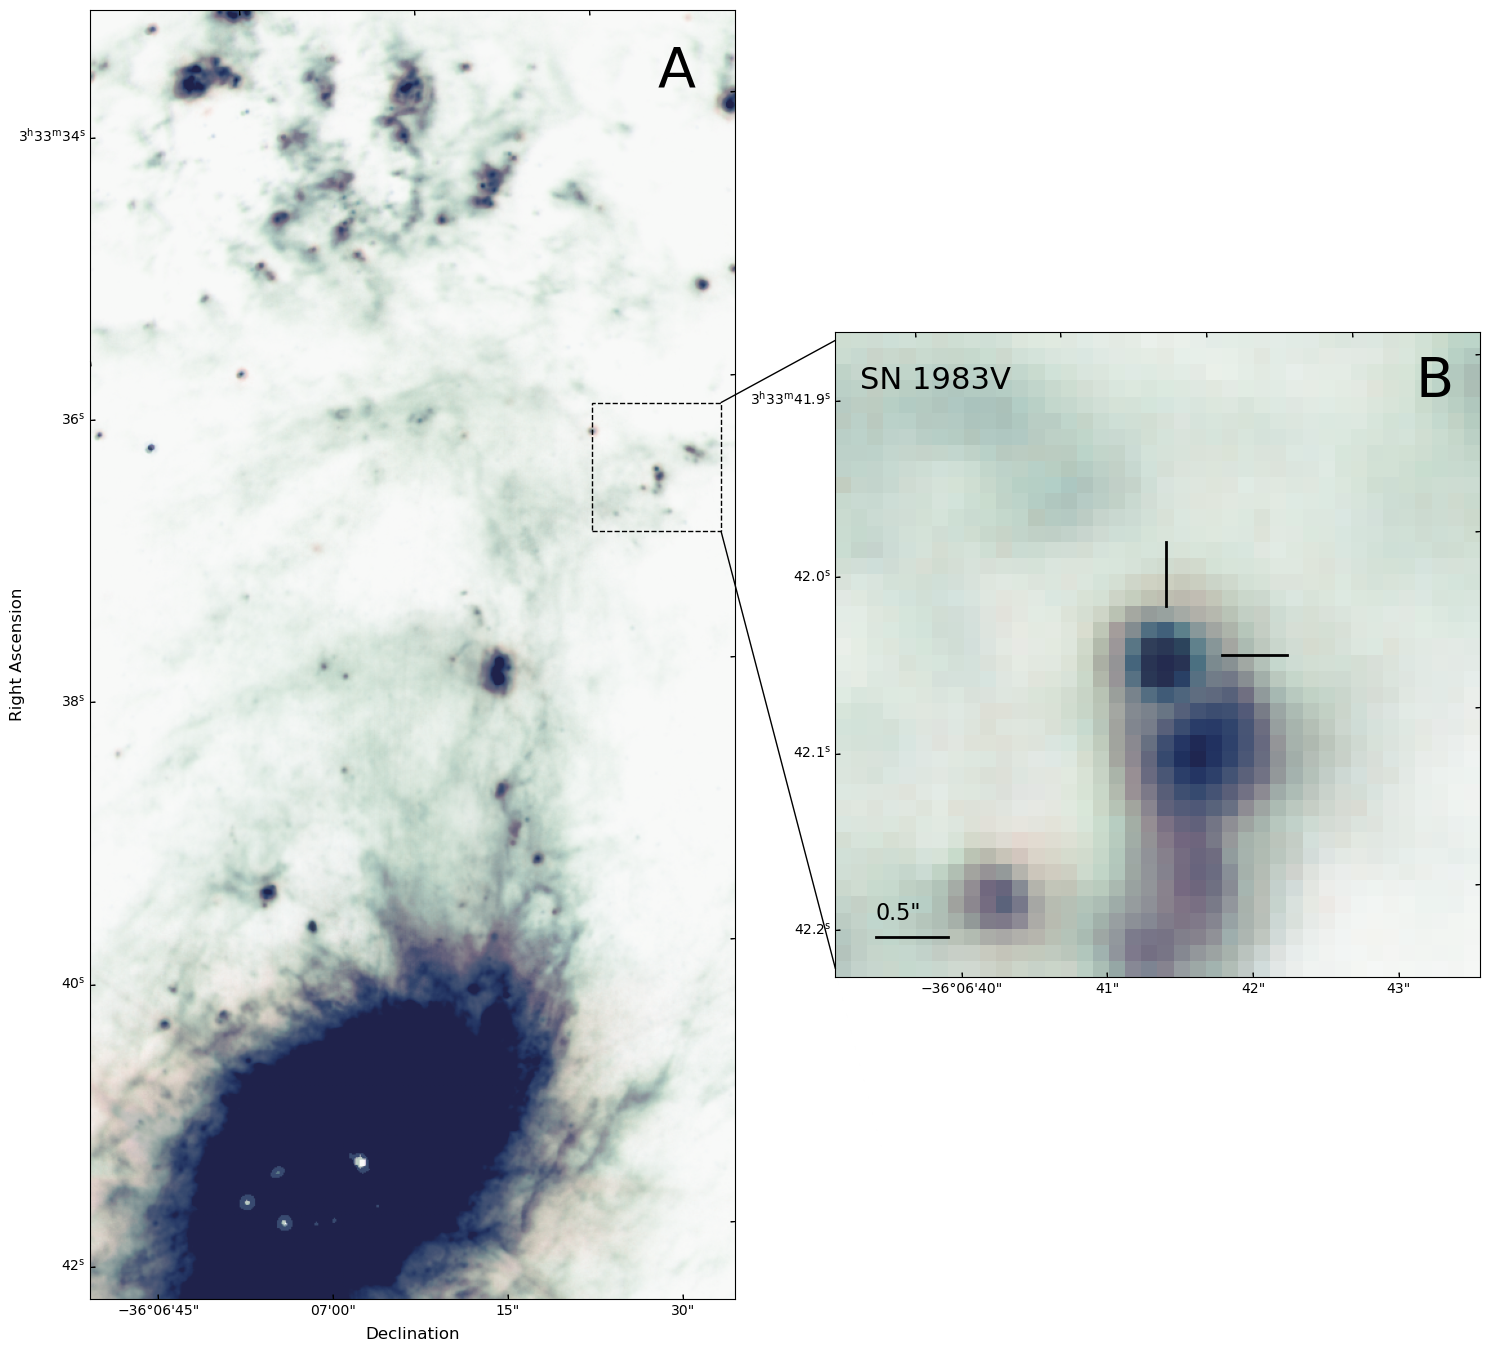

In [38]:
fig = plt.figure(figsize=(15, 15))

#############
# TOP SMALL SQUARE
sub1 = fig.add_subplot(1,2,2, projection= wcs) # one rows, two columns, second cell

# Overlay images with transparency and different colormaps
sub1.imshow(miri_2100_reproj[crop_small], norm=inorm0, cmap='Reds', alpha=1, vmin=ivmin0, vmax=ivmax0)
sub1.imshow(miri_1130_reproj[crop_small], norm=inorm0, cmap='Greens', alpha=0.6, vmin=ivmin0, vmax=ivmax0)
sub1.imshow(miri_1000_reproj[crop_small], norm=inorm0, cmap='Blues', alpha=0.5, vmin=ivmin0, vmax=ivmax0)
sub1.imshow(miri_770_data[crop_small], norm=inorm0, cmap='Purples', alpha=0.2, vmin=ivmin0, vmax=ivmax0)

sub1.set_xlabel('', fontsize = 12)
sub1.set_ylabel('', fontsize = 12, labelpad = 0.0001)
sub1.tick_params(axis='x', direction='in')
sub1.tick_params(axis='y', direction='in')

#############
# BIG FIGURE
sub3 = fig.add_subplot(1,2,1, projection=wcs) # one rows, two columns, first cell

# Overlay images with transparency and different colormaps
sub3.imshow(miri_2100_reproj[crop_big], norm=inorm1, cmap='Reds', alpha=1, vmin=ivmin1, vmax=ivmax1)
sub3.imshow(miri_1130_reproj[crop_big], norm=inorm1, cmap='Greens', alpha=0.6, vmin=ivmin1, vmax=ivmax1)
sub3.imshow(miri_1000_reproj[crop_big], norm=inorm1, cmap='Blues', alpha=0.5, vmin=ivmin1, vmax=ivmax1)
sub3.imshow(miri_770_data[crop_big], norm=inorm1, cmap='Purples', alpha=0.2, vmin=ivmin1, vmax=ivmax1)

sub3.set_xlabel('Declination', fontsize = 12)
sub3.set_ylabel('Right Ascension', fontsize = 12, labelpad = 0.0001)
sub3.tick_params(axis='x', direction='in')
sub3.tick_params(axis='y', direction='in')

#############
# Color bar
# cbar = fig.colorbar(im, orientation='horizontal', pad = 0.1)
# cbar.set_label(r"RHT $\theta$ ($^\circ$)", fontsize = 22)

#############
# Add Labels
sub3.text(440, 940, 'A', fontsize=40, color = 'black') #, fontweight = 'bold'
sub1.text(35.5, 35.5, 'B', fontsize=40, color = 'black')

#############
# Add Zoom-in square (need to make this more generic); Plots with Bottom Left corner
# x1 = 53.3835165 # RA
# y1 = -36.1471056 # DEC

x1 = 389
y1 = 595
    
sub3.add_patch(plt.Rectangle((x1,y1), width = 100, height = 100, ls="--", color = 'black', fill=False))
    
#############
# Plot connecting lines
con1 = ConnectionPatch(xyA=(-0.5, 39), coordsA=sub1.transData, 
                       xyB=(489, 695), coordsB=sub3.transData, color = 'black', linewidth = 1, alpha = 1)
fig.add_artist(con1)

con2 = ConnectionPatch(xyA=(-0.5, 0), coordsA=sub1.transData, 
                       xyB=(489, 595), coordsB=sub3.transData, color = 'black', linewidth = 1, alpha = 1)
fig.add_artist(con2)

# #############
# # Plot circle ID-ing SN in zoomed-in; Plots from center of circle
# x = 49
# y = 49
# sub1.add_patch(plt.Circle((x,y), radius=8, color='black', linestyle= '--', fill=False))

#############
# Plot cross hairs
hx_line = [(window-0.5)+4, (window-0.5)+8]
hy_line = [(window-0.5), (window-0.5)]

vx_line = [(window), (window)]
vy_line = [(window-0.5)+3, (window-0.5)+7]

sub1.plot(hx_line, hy_line, color='black', linewidth=2, linestyle='-')
sub1.plot(vx_line, vy_line, color='black', linewidth=2, linestyle='-')

#############
# Scale bar
x0 = 2
y0 = 2
sc_x = [x0, x0+4.5] # MIRI = 0.672" = 6.05 pixels
sc_y = [y0, y0]

sub1.plot(sc_x, sc_y, color='black', linewidth=2, linestyle='-')
sub1.text(2, 3, '0.5"', fontsize=16, color = 'black')
#############
# Plot Text IDing
sub1.text(1, 36, 'SN 1983V', fontsize=22, color = 'black')

plt.tight_layout()

plt.savefig('/Users/sophiakressy/Desktop/MIRI_83V_zoom.pdf')


In [ ]:
# TO DO

# * Location of SN in RA + Dec
# [3:33:31.6159, -36:08:55.222] #sexagesmial, IRCS
# [53.3817412, -36.1486795] # degrees, fk5
# [1140.0925, 1244.2278] # image, pixels

# * Crop image by just adjusting x and y axis length

# * fix X,Y labels

# * color bar

# * visually check orientation of galaxy

# * overlay other images

# * make it look nice with scaling

# overlay circle to label SN

# zoom in image, 50x50 pixels outside SN location seems good